In [2]:
import pandas as pd

df = pd.read_csv("../data/bank_transactions.csv")
df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


## Data Cleaning & Preparation

This notebook focuses on transforming raw banking transaction data
into a structured format suitable for data warehousing and analytics.

In [3]:
df.shape

(1048567, 9)

In [4]:
df.dtypes

TransactionID               object
CustomerID                  object
CustomerDOB                 object
CustGender                  object
CustLocation                object
CustAccountBalance         float64
TransactionDate             object
TransactionTime              int64
TransactionAmount (INR)    float64
dtype: object

In [5]:
df.describe()

,CustAccountBalance,TransactionTime,TransactionAmount (INR)
count,1.046198e+06,1.048567e+06,1.048567e+06
mean,1.154035e+05,1.570875e+05,1.574335e+03
std,8.464854e+05,5.126185e+04,6.574743e+03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.721760e+03,1.240300e+05,1.610000e+02
50%,1.679218e+04,1.642260e+05,4.590300e+02
75%,5.765736e+04,2.000100e+05,1.200000e+03
max,1.150355e+08,2.359590e+05,1.560035e+06


In [6]:
df.isnull().sum()

TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance         2369
TransactionDate               0
TransactionTime               0
TransactionAmount (INR)       0
dtype: int64

In [8]:
## Standardized column naming conventions to ensure compatibility with SQL-based data warehouse modeling
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

C:\Users\Eser\AppData\Local\Temp\ipykernel_30548\2071245215.py:2: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")
C:\Users\Eser\AppData\Local\Temp\ipykernel_30548\2071245215.py:2: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")


In [28]:
## Converted transaction timestamps into standardized datetime format, 
## handling inconsistencies and invalid values using safe parsing strategies*/
df["TransactionDate"] = pd.to_datetime(
    df["TransactionDate"],
    dayfirst=True,
    errors="coerce"
)

In [29]:
## Parsed inconsistent date-of-birth values into a standardized datetime format, handling ambiguous and invalid entries safely.
df["CustomerDOB"] = pd.to_datetime(
    df["CustomerDOB"],
    dayfirst=True,
    errors="coerce"
)

In [11]:
## Corrected misinterpreted date-of-birth values caused by two-digit year parsing by applying a rule-based century adjustment.
df["CustomerDOB"] = df["CustomerDOB"].apply(
    lambda x: x.replace(year=x.year - 100) if x.year > 2026 else x
)

In [12]:
## Derived customer age from date-of-birth to enable segmentation and behavioral analysis
df["Age"] = 2026 - df["CustomerDOB"].dt.year

In [13]:
## Handled unrealistic age values by applying business rules and preserving records while nullifying invalid attributes.
df.loc[(df["Age"] < 18) | (df["Age"] > 90), "Age"] = None

In [14]:
df[["CustomerDOB", "Age"]].head(20)

,CustomerDOB,Age
0,1994-01-10,32.0
1,1957-04-04,69.0
2,1996-11-26,30.0
3,1973-09-14,53.0
4,1988-03-24,38.0
5,1972-10-08,54.0
6,1992-01-26,34.0
7,1982-01-27,44.0
8,1988-04-19,38.0
9,1984-06-22,42.0


In [15]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18, 25, 35, 50, 65, 100],
    labels=["18-25", "26-35", "36-50", "51-65", "65+"]
)

In [16]:
df["CustAccountBalance"].describe()

count    1.046198e+06
mean     1.154035e+05
std      8.464854e+05
min      0.000000e+00
25%      4.721760e+03
50%      1.679218e+04
75%      5.765736e+04
max      1.150355e+08
Name: CustAccountBalance, dtype: float64

In [17]:
threshold = df["CustAccountBalance"].quantile(0.95)

df["HighBalanceFlag"] = df["CustAccountBalance"].apply(
    lambda x: 1 if x >= threshold else 0
)

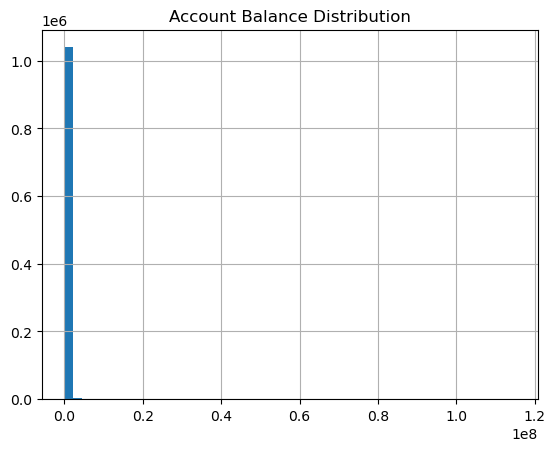

In [18]:
## Customer balances show a highly skewed distribution, indicating that a small portion of 
## customers holds the majority of total assets
import matplotlib.pyplot as plt

df["CustAccountBalance"].hist(bins=50)
plt.title("Account Balance Distribution")
plt.show()

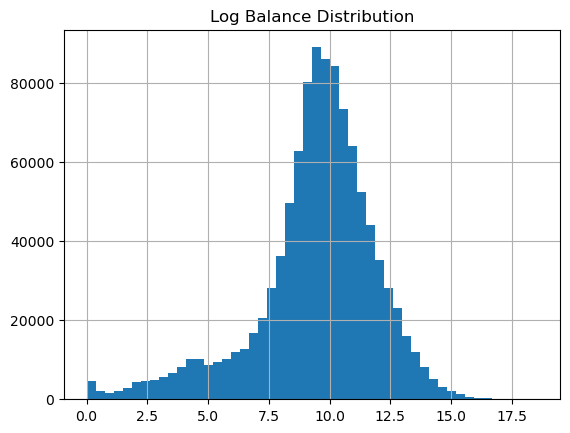

In [20]:
## After applying log transformation, customer balances exhibited an approximately normal distribution, indicating a 
## typical log-normal behavior common in financial dataset
import numpy as np

np.log1p(df["CustAccountBalance"]).hist(bins=50)
plt.title("Log Balance Distribution")
plt.show()

In [21]:
# Checked for duplicate transaction IDs to ensure primary key uniqueness
df["TransactionID"].duplicated().sum()

0

In [22]:
# Verified that all transactions are linked to a valid customer (no missing CustomerID)
df["CustomerID"].isnull().sum()

0

In [23]:
# Standardized location values by removing extra spaces and converting to uppercase
# to avoid duplicate categories caused by inconsistent text formatting
df["CustLocation"] = df["CustLocation"].str.upper().str.strip()

In [31]:
# Filled missing gender values with 'Unknown' to preserve records
# while avoiding loss of information in customer dimension
df["CustGender"] = df["CustGender"].fillna("Unknown")

In [32]:
# Replaced missing location values with 'Unknown' to maintain dimensional consistency
df["CustLocation"] = df["CustLocation"].fillna("Unknown")

In [34]:
# Imputed missing account balance values using median to reduce skewness impact
# and preserve realistic distribution of financial data
df["CustAccountBalance"] = df["CustAccountBalance"].fillna(
    df["CustAccountBalance"].median()
)
df["CustAccountBalance"] = df["CustAccountBalance"].fillna(
    df["CustAccountBalance"].median()
)

In [30]:
df.dtypes

TransactionID                      object
CustomerID                         object
CustomerDOB                datetime64[ns]
CustGender                         object
CustLocation                       object
CustAccountBalance                float64
TransactionDate            datetime64[ns]
TransactionTime                     int64
TransactionAmount (INR)           float64
dtype: object

In [35]:
df.isnull().sum()

TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                    0
CustLocation                  0
CustAccountBalance            0
TransactionDate               0
TransactionTime               0
TransactionAmount (INR)       0
dtype: int64

In [36]:
df

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0
3,T4,C5342380,2073-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.0
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5
...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,1990-04-08,M,NEW DELHI,7635.19,2016-09-18,184824,799.0
1048563,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,2016-09-18,183734,460.0
1048564,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,2016-09-18,183313,770.0
1048565,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,2016-09-18,184706,1000.0


In [37]:
df.to_parquet("../data/processed/clean_transactions.parquet", index=False)